In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


In [7]:
CSV_FILE_PATH = "/content/Leads X Education.csv"
df = pd.read_csv("/content/Leads X Education.csv")


In [8]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 records:")
display(df.head())

print("\nBasic information:")
df.info()

print("\nSummary for categorical columns:")
display(df.describe(include="object"))

print("\nSummary for numerical columns:")
display(df.describe(include=np.number))

Rows and columns: (9240, 37)

Column names:
['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Lead Quality', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']

Data types:
Prospect ID                                       object
Lead Number             

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified



Basic information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit            

,Prospect ID,Lead Origin,Lead Source,Do Not Email,Do Not Call,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,...,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
count,9240,9240,9204,9240,9240,9137,6779,7802,7033,6550,...,4473,9240,9240,6531,7820,5022,5022,9240,9240,9240
unique,9240,5,21,2,2,17,38,19,10,6,...,5,1,1,6,7,3,3,1,2,16
top,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,Landing Page Submission,Google,No,No,Email Opened,India,Select,Select,Unemployed,...,Might be,No,No,Select,Mumbai,02.Medium,02.Medium,No,No,Modified
freq,1,4886,2868,8506,9238,3437,6492,1942,5043,5600,...,1560,9240,9240,4146,3222,3839,2788,9240,6352,3407



Summary for numerical columns:


,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [9]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 records:")
display(df.head())

print("\nBasic information:")
df.info()

print("\nSummary for categorical columns:")
display(df.describe(include="object"))

print("\nSummary for numerical columns:")
display(df.describe(include=np.number))

Rows and columns: (9240, 37)

Column names:
['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Lead Quality', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']

Data types:
Prospect ID                                       object
Lead Number             

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified



Basic information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit            

,Prospect ID,Lead Origin,Lead Source,Do Not Email,Do Not Call,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,...,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
count,9240,9240,9204,9240,9240,9137,6779,7802,7033,6550,...,4473,9240,9240,6531,7820,5022,5022,9240,9240,9240
unique,9240,5,21,2,2,17,38,19,10,6,...,5,1,1,6,7,3,3,1,2,16
top,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,Landing Page Submission,Google,No,No,Email Opened,India,Select,Select,Unemployed,...,Might be,No,No,Select,Mumbai,02.Medium,02.Medium,No,No,Modified
freq,1,4886,2868,8506,9238,3437,6492,1942,5043,5600,...,1560,9240,9240,4146,3222,3839,2788,9240,6352,3407



Summary for numerical columns:


,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [10]:
df = df.rename(
    columns={
        "Prospect ID": "prospect_id",
        "Lead Number": "lead_number",
        "Lead Origin": "lead_origin",
        "Lead Source": "lead_source",
        "Last Activity": "last_activity",
        "Tags": "tags",
        "What is your current occupation": "occupation",
        "Converted": "converted",
    }
)

df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("/", "_")
)

print(df.columns.tolist())

target_column = "converted"

if target_column not in df.columns:
    raise ValueError(
        "Target column not found. Please make sure your CSV contains a column named "
        "'Converted'. If your target has another name, update target_column."
    )

df[target_column] = pd.to_numeric(df[target_column], errors="coerce")
df = df.dropna(subset=[target_column])
df[target_column] = df[target_column].astype(int)

df = df.replace("Select", np.nan)


['prospect_id', 'lead_number', 'lead_origin', 'lead_source', 'do_not_email', 'do_not_call', 'converted', 'totalvisits', 'total_time_spent_on_website', 'page_views_per_visit', 'last_activity', 'country', 'specialization', 'how_did_you_hear_about_x_education', 'occupation', 'what_matters_most_to_you_in_choosing_a_course', 'search', 'magazine', 'newspaper_article', 'x_education_forums', 'newspaper', 'digital_advertisement', 'through_recommendations', 'receive_more_updates_about_our_courses', 'tags', 'lead_quality', 'update_me_on_supply_chain_content', 'get_updates_on_dm_content', 'lead_profile', 'city', 'asymmetrique_activity_index', 'asymmetrique_profile_index', 'asymmetrique_activity_score', 'asymmetrique_profile_score', 'i_agree_to_pay_the_amount_through_cheque', 'a_free_copy_of_mastering_the_interview', 'last_notable_activity']


,missing_count,missing_percent
how_did_you_hear_about_x_education,7250,78.463203
lead_profile,6855,74.188312
lead_quality,4767,51.590909
asymmetrique_profile_index,4218,45.649351
asymmetrique_activity_index,4218,45.649351
asymmetrique_activity_score,4218,45.649351
asymmetrique_profile_score,4218,45.649351
city,3669,39.707792
specialization,3380,36.580087
tags,3353,36.287879


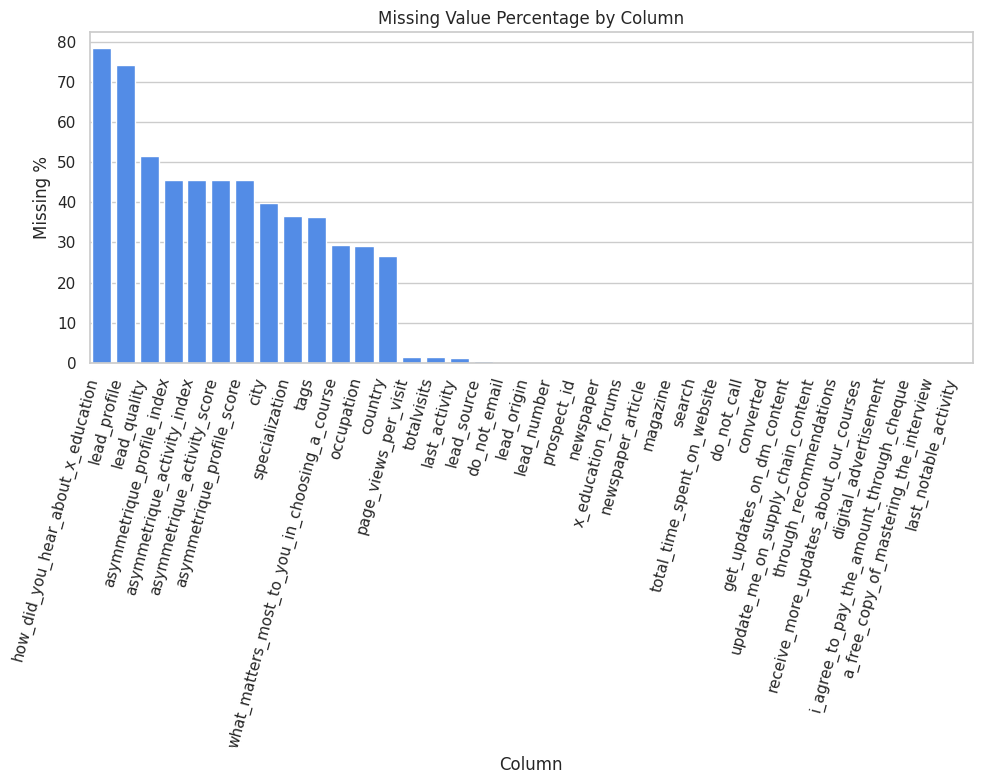

In [14]:
missing_count = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame(
    {"missing_count": missing_count, "missing_percent": missing_percent}
)

display(missing_table)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=missing_table.index,
    y=missing_table["missing_percent"],
    color="#3A86FF",
)
plt.xticks(rotation=75, ha="right")
plt.title("Missing Value Percentage by Column")
plt.ylabel("Missing %")
plt.xlabel("Column")
plt.tight_layout()
plt.show()

In [16]:
print("Duplicate rows:", df.duplicated().sum())

possible_id_columns = [
    "prospect_id",
    "lead_number",
    "lead_id",
    "id",
]
id_columns = [col for col in possible_id_columns if col in df.columns]

if id_columns:
    for col in id_columns:
        print(f"Unique {col}:", df[col].nunique())
else:
    print("No obvious ID column found.")

print("Total rows:", len(df))

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Duplicate rows: 0
Unique prospect_id: 9240
Unique lead_number: 9240
Total rows: 9240
prospect_id: 9240 unique values
lead_number: 9240 unique values
lead_origin: 5 unique values
lead_source: 21 unique values
do_not_email: 2 unique values
do_not_call: 2 unique values
converted: 2 unique values
totalvisits: 41 unique values
total_time_spent_on_website: 1731 unique values
page_views_per_visit: 114 unique values
last_activity: 17 unique values
country: 38 unique values
specialization: 18 unique values
how_did_you_hear_about_x_education: 9 unique values
occupation: 6 unique values
what_matters_most_to_you_in_choosing_a_course: 3 unique values
search: 2 unique values
magazine: 1 unique values
newspaper_article: 2 unique values
x_education_forums: 2 unique values
newspaper: 2 unique values
digital_advertisement: 2 unique values
through_recommendations: 2 unique values
receive_more_updates_about_our_courses: 1 unique values
tags: 26 unique values
lead_quality: 5 unique values
update_me_on_supp

Target distribution:
converted
0    5679
1    3561
Name: count, dtype: int64

Overall conversion rate: 38.54%


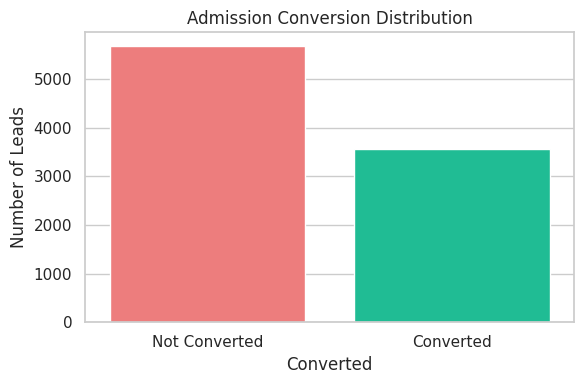

In [17]:
conversion_counts = df["converted"].value_counts().sort_index()
conversion_rate = df["converted"].mean() * 100

print("Target distribution:")
print(conversion_counts)
print(f"\nOverall conversion rate: {conversion_rate:.2f}%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="converted", palette=["#FF6B6B", "#06D6A0"])
plt.title("Admission Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Number of Leads")
plt.xticks([0, 1], ["Not Converted", "Converted"])
plt.tight_layout()
plt.show()

Categorical columns used for EDA: ['lead_origin', 'lead_source', 'last_activity', 'tags', 'occupation']

Top values in lead_origin:


,count
lead_origin,
Landing Page Submission,4886
API,3580
Lead Add Form,718
Lead Import,55
Quick Add Form,1


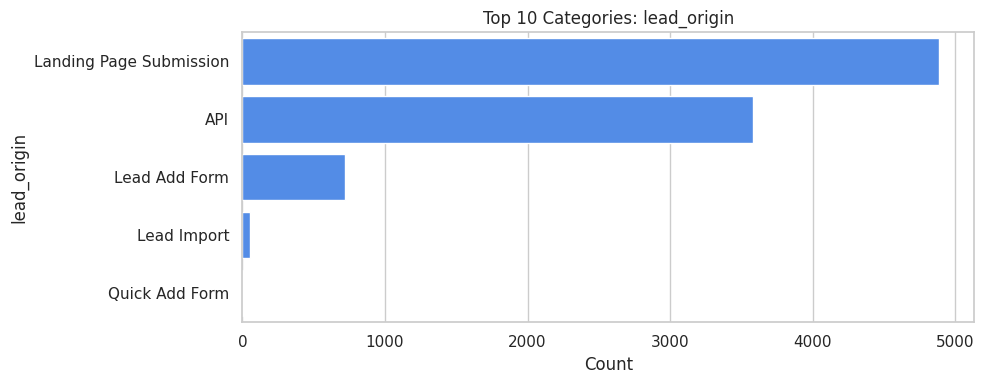


Top values in lead_source:


,count
lead_source,
Google,2868
Direct Traffic,2543
Olark Chat,1755
Organic Search,1154
Reference,534
Welingak Website,142
Referral Sites,125
Facebook,55
NaN,36


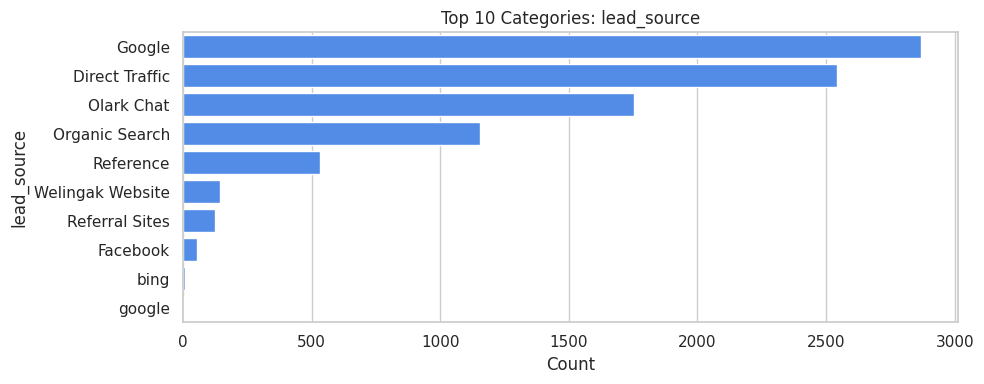


Top values in last_activity:


,count
last_activity,
Email Opened,3437
SMS Sent,2745
Olark Chat Conversation,973
Page Visited on Website,640
Converted to Lead,428
Email Bounced,326
Email Link Clicked,267
Form Submitted on Website,116
NaN,103


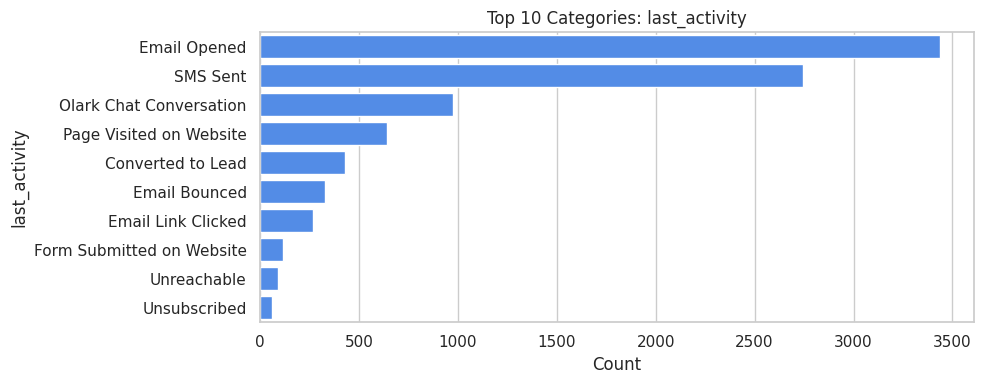


Top values in tags:


,count
tags,
NaN,3353
Will revert after reading the email,2072
Ringing,1203
Interested in other courses,513
Already a student,465
Closed by Horizzon,358
switched off,240
Busy,186
Lost to EINS,175


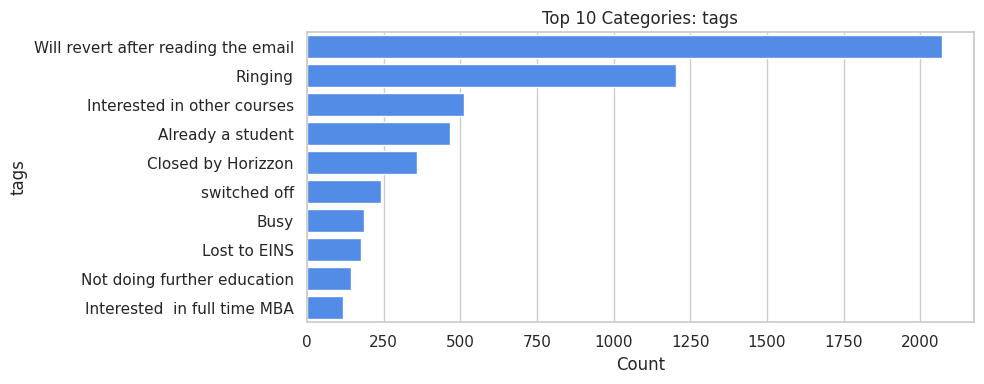


Top values in occupation:


,count
occupation,
Unemployed,5600
NaN,2690
Working Professional,706
Student,210
Other,16
Housewife,10
Businessman,8


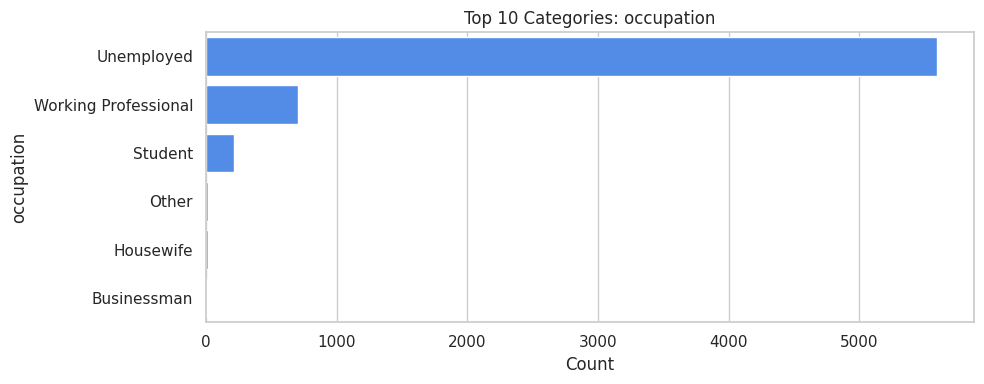

In [18]:
preferred_categorical_columns = [
    "lead_origin",
    "lead_source",
    "last_activity",
    "tags",
    "occupation",
]

categorical_columns = [
    col for col in preferred_categorical_columns if col in df.columns
]

if not categorical_columns:
    categorical_columns = (
        df.drop(columns=[target_column])
        .select_dtypes(include=["object", "category", "bool"])
        .columns.tolist()
    )

print("Categorical columns used for EDA:", categorical_columns)

for col in categorical_columns:
    print(f"\nTop values in {col}:")
    display(df[col].value_counts(dropna=False).head(10))

    plt.figure(figsize=(10, 4))
    top_values = df[col].value_counts().head(10).index
    sns.countplot(
        data=df[df[col].isin(top_values)],
        y=col,
        order=top_values,
        color="#3A86FF",
    )
    plt.title(f"Top 10 Categories: {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


Conversion rate by lead_origin:


,lead_count,conversion_rate
lead_origin,,
Quick Add Form,1,100.000000
Lead Add Form,718,92.479109
Landing Page Submission,4886,36.185018
API,3580,31.145251
Lead Import,55,23.636364


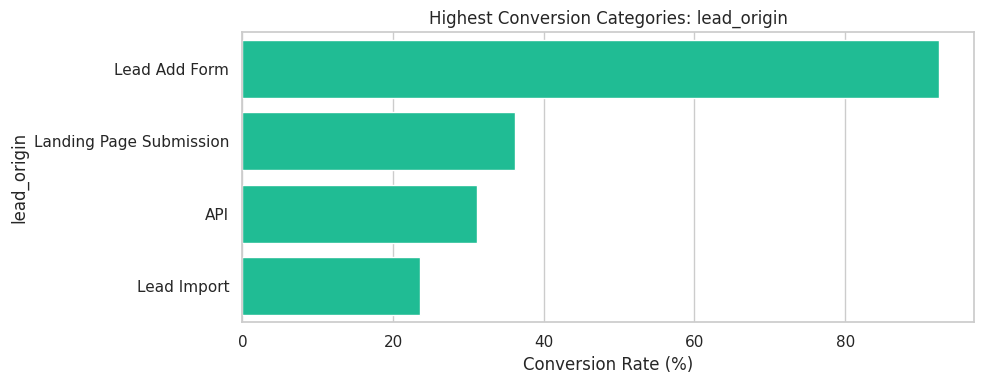


Conversion rate by lead_source:


,lead_count,conversion_rate
lead_source,,
Live Chat,2,100.000000
WeLearn,1,100.000000
NC_EDM,1,100.000000
Welingak Website,142,98.591549
Reference,534,91.760300
Click2call,4,75.000000
Social Media,2,50.000000
Google,2868,39.993026
Organic Search,1154,37.781629


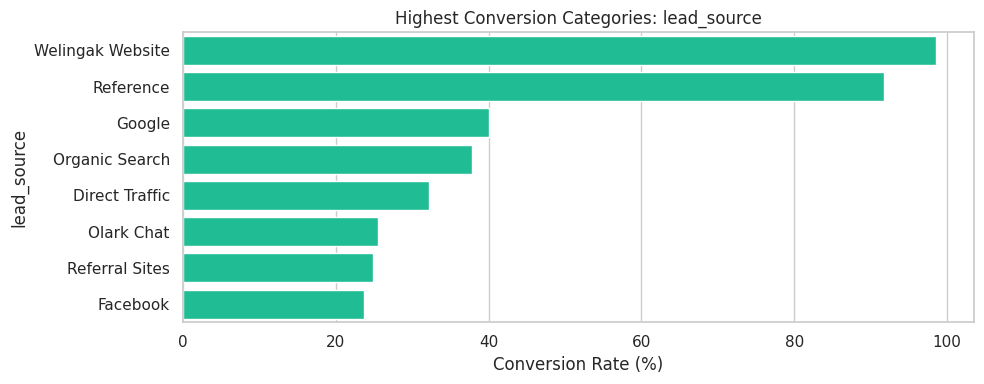


Conversion rate by last_activity:


,lead_count,conversion_rate
last_activity,,
Approached upfront,9,100.000000
Email Marked Spam,2,100.000000
Email Received,2,100.000000
Resubscribed to emails,1,100.000000
Had a Phone Conversation,30,73.333333
SMS Sent,2745,62.914390
Email Opened,3437,36.456212
Unreachable,93,33.333333
Email Link Clicked,267,27.340824


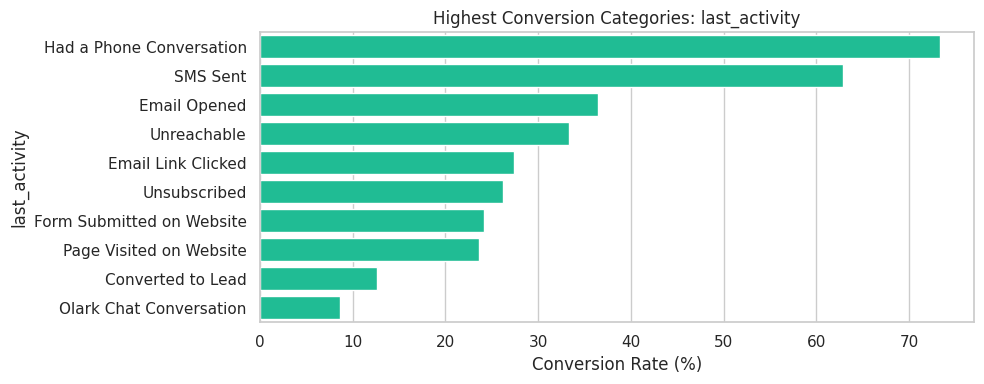


Conversion rate by tags:


,lead_count,conversion_rate
tags,,
Interested in Next batch,5,100.000000
Lateral student,3,100.000000
Closed by Horizzon,358,99.441341
Lost to EINS,175,97.714286
Will revert after reading the email,2072,96.862934
Busy,186,56.451613
Shall take in the next coming month,2,50.000000
Want to take admission but has financial problems,6,33.333333
in touch with EINS,12,25.000000


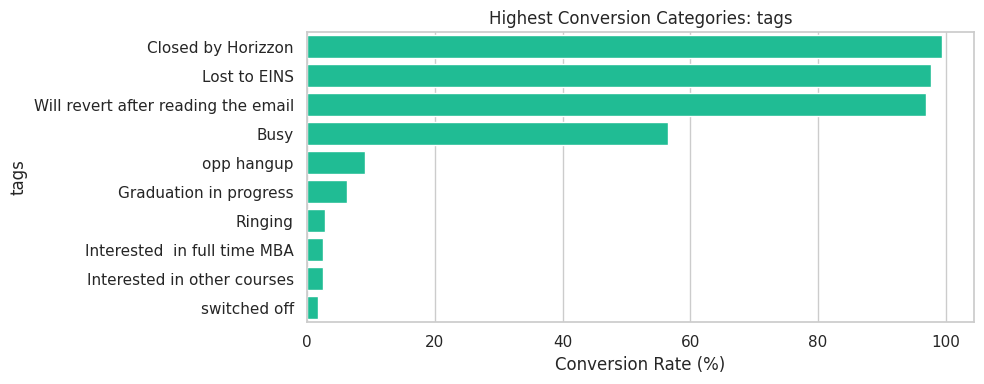


Conversion rate by occupation:


,lead_count,conversion_rate
occupation,,
Housewife,10,100.000000
Working Professional,706,91.643059
Businessman,8,62.500000
Other,16,62.500000
Unemployed,5600,43.589286
Student,210,37.142857


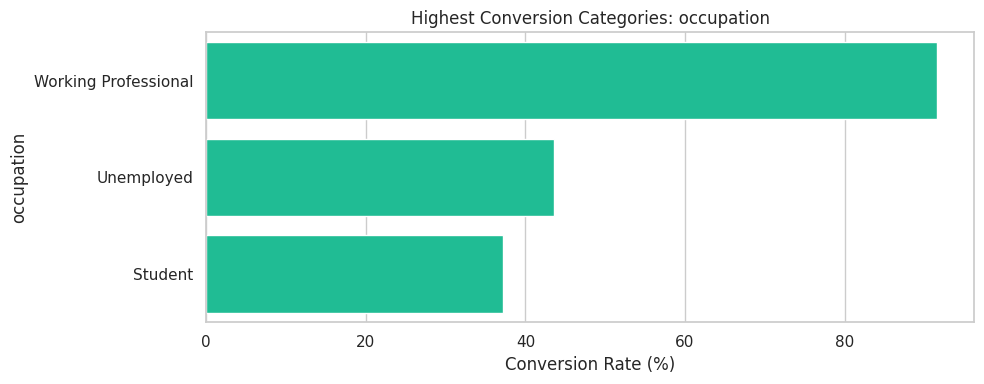

In [19]:
for col in categorical_columns:
    conversion_by_category = (
        df.groupby(col)["converted"]
        .agg(["count", "mean"])
        .rename(columns={"count": "lead_count", "mean": "conversion_rate"})
        .sort_values("conversion_rate", ascending=False)
    )
    conversion_by_category["conversion_rate"] *= 100

    print(f"\nConversion rate by {col}:")
    display(conversion_by_category.head(15))

    plot_data = conversion_by_category[conversion_by_category["lead_count"] >= 20].head(10)
    plt.figure(figsize=(10, 4))
    sns.barplot(
        data=plot_data.reset_index(),
        x="conversion_rate",
        y=col,
        color="#06D6A0",
    )
    plt.title(f"Highest Conversion Categories: {col}")
    plt.xlabel("Conversion Rate (%)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [20]:
df_clean = df.copy()

# Replace missing categorical values with an explicit label for EDA clarity.
for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna("Unknown")
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Group rare categories to reduce one-hot encoding noise.
def group_rare_categories(data, column, min_count=20):
    value_counts = data[column].value_counts()
    rare_values = value_counts[value_counts < min_count].index
    data[column] = data[column].replace(rare_values, "Other")
    return data


for col in categorical_columns:
    df_clean = group_rare_categories(df_clean, col, min_count=20)

print("Cleaned category counts:")
for col in categorical_columns:
    print(f"\n{col}")
    print(df_clean[col].value_counts())

Cleaned category counts:

lead_origin
lead_origin
Landing Page Submission    4886
API                        3580
Lead Add Form               718
Lead Import                  55
Other                         1
Name: count, dtype: int64

lead_source
lead_source
Google              2868
Direct Traffic      2543
Olark Chat          1755
Organic Search      1154
Reference            534
Welingak Website     142
Referral Sites       125
Facebook              55
Unknown               36
Other                 28
Name: count, dtype: int64

last_activity
last_activity
Email Opened                 3437
SMS Sent                     2745
Olark Chat Conversation       973
Page Visited on Website       640
Converted to Lead             428
Email Bounced                 326
Email Link Clicked            267
Form Submitted on Website     116
Unknown                       103
Unreachable                    93
Unsubscribed                   61
Had a Phone Conversation       30
Other                     

In [21]:

columns_to_drop = id_columns + [target_column]
X = df_clean.drop(columns=columns_to_drop, errors="ignore")
y = df_clean[target_column]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Train conversion rate:", round(y_train.mean() * 100, 2))
print("Test conversion rate:", round(y_test.mean() * 100, 2))

Feature shape: (9240, 34)
Target shape: (9240,)
Training rows: 7392
Testing rows: 1848
Train conversion rate: 38.54
Test conversion rate: 38.53


In [22]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Numeric features: ['totalvisits', 'total_time_spent_on_website', 'page_views_per_visit', 'asymmetrique_activity_score', 'asymmetrique_profile_score']
Categorical features: ['lead_origin', 'lead_source', 'do_not_email', 'do_not_call', 'last_activity', 'country', 'specialization', 'how_did_you_hear_about_x_education', 'occupation', 'what_matters_most_to_you_in_choosing_a_course', 'search', 'magazine', 'newspaper_article', 'x_education_forums', 'newspaper', 'digital_advertisement', 'through_recommendations', 'receive_more_updates_about_our_courses', 'tags', 'lead_quality', 'update_me_on_supply_chain_content', 'get_updates_on_dm_content', 'lead_profile', 'city', 'asymmetrique_activity_index', 'asymmetrique_profile_index', 'i_agree_to_pay_the_amount_through_cheque', 'a_free_copy_of_mastering_the_interview', 'last_notable_activity']


Model evaluation:
Accuracy: 0.9378
Precision: 0.9106
Recall: 0.9298
F1 Score: 0.9201
ROC AUC: 0.9786

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1136
           1       0.91      0.93      0.92       712

    accuracy                           0.94      1848
   macro avg       0.93      0.94      0.93      1848
weighted avg       0.94      0.94      0.94      1848



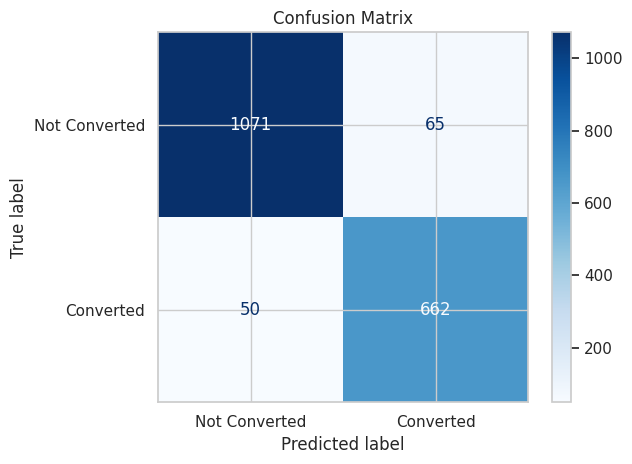

In [23]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
        ),
    ]
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Model evaluation:")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not Converted", "Converted"]).plot(
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [24]:
train_processed = X_train.copy()
train_processed[target_column] = y_train

test_processed = X_test.copy()
test_processed[target_column] = y_test

train_processed.to_csv("admission_conversion_train_clean.csv", index=False)
test_processed.to_csv("admission_conversion_test_clean.csv", index=False)

print("Saved files:")
print("admission_conversion_train_clean.csv")
print("admission_conversion_test_clean.csv")

Saved files:
admission_conversion_train_clean.csv
admission_conversion_test_clean.csv


In [25]:
print(
    """
1. The target column is Converted, where 1 means the lead converted/admitted.
2. The dataset is mostly categorical, so one-hot encoding is required.
3. Lead source, lead origin, last activity, tags, and occupation are useful for understanding conversion behavior.
4. Rare categories were grouped as Other to reduce noise.
5. A Logistic Regression baseline model was trained after preprocessing.
"""
)



Final observations to write in your project:
1. The target column is Converted, where 1 means the lead converted/admitted.
2. The dataset is mostly categorical, so one-hot encoding is required.
3. Lead source, lead origin, last activity, tags, and occupation are useful for understanding conversion behavior.
4. Rare categories were grouped as Other to reduce noise.
5. A Logistic Regression baseline model was trained after preprocessing.

